<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import digit dataset
from sklearn.datasets import load_digits
df = load_digits()




df

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [ ]:
X = df.data
y = df.target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1437, 64)
X_test shape: (360, 64)
y_train shape: (1437,)
y_test shape: (360,)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold

k_values = list(range(1, 21))
print(f"K-values to evaluate: {k_values}")

K-values to evaluate: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [ ]:
accuracy_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    fold_accuracies = []
    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        knn.fit(X_train_fold, y_train_fold)
        score = knn.score(X_val_fold, y_val_fold)
        fold_accuracies.append(score)
    accuracy_scores.append(sum(fold_accuracies) / len(fold_accuracies))

print("Cross-validation accuracy scores for each k:")
for k, score in zip(k_values, accuracy_scores):
    print(f"k={k}: {score:.4f}")

Cross-validation accuracy scores for each k:
k=1: 0.9882
k=2: 0.9826
k=3: 0.9861
k=4: 0.9833
k=5: 0.9819
k=6: 0.9805
k=7: 0.9819
k=8: 0.9777
k=9: 0.9770
k=10: 0.9763
k=11: 0.9742
k=12: 0.9736
k=13: 0.9736
k=14: 0.9715
k=15: 0.9680
k=16: 0.9694
k=17: 0.9673
k=18: 0.9652
k=19: 0.9624
k=20: 0.9617


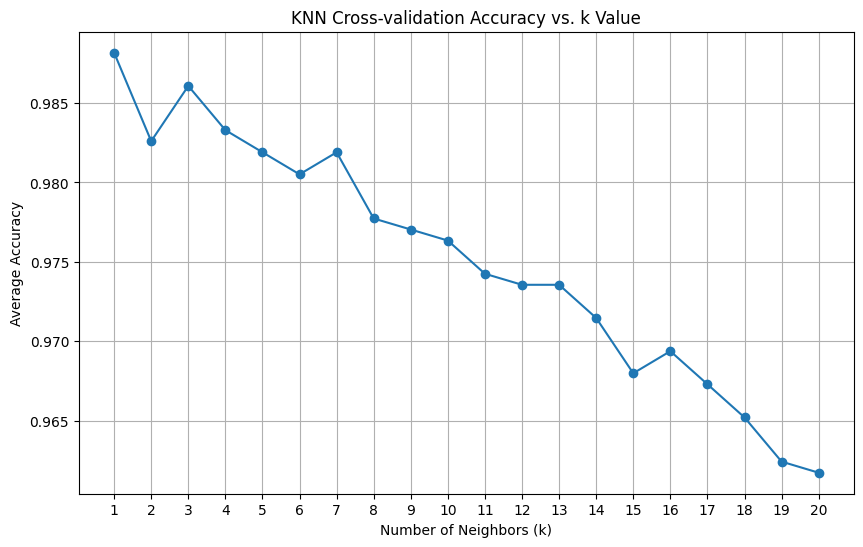

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-')
plt.title('KNN Cross-validation Accuracy vs. k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### Plotting Sample Digits

We can visualize individual digits from the dataset using `matplotlib.pyplot`. The `df.images` attribute stores the 8x8 pixel data for each digit.

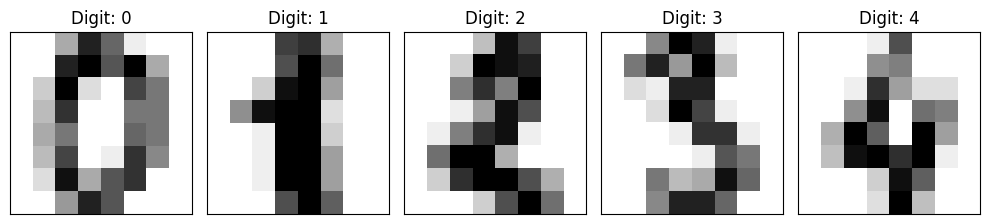

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 5))
for i, ax in enumerate(axes):
    ax.imshow(df.images[i], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Digit: {df.target[i]}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
# Train a KNN model with k=7 on the entire training data
knn_k7 = KNeighborsClassifier(n_neighbors=7)
knn_k7.fit(X_train, y_train)

print("KNN model with k=7 trained successfully.")

KNN model with k=7 trained successfully.


In [ ]:
import numpy as np

# Select two random indices from the test set
np.random.seed(24) # for reproducibility
random_indices = np.random.choice(len(X_test), 2, replace=False)

sample_X = X_test[random_indices]
sample_y_true = y_test[random_indices]

# Predict the labels for these two samples
sample_y_pred = knn_k7.predict(sample_X)

print(f"Selected test sample indices: {random_indices}")
print(f"Actual labels for selected samples: {sample_y_true}")
print(f"Predicted labels for selected samples: {sample_y_pred}")

Selected test sample indices: [126 142]
Actual labels for selected samples: [2 4]
Predicted labels for selected samples: [2 4]


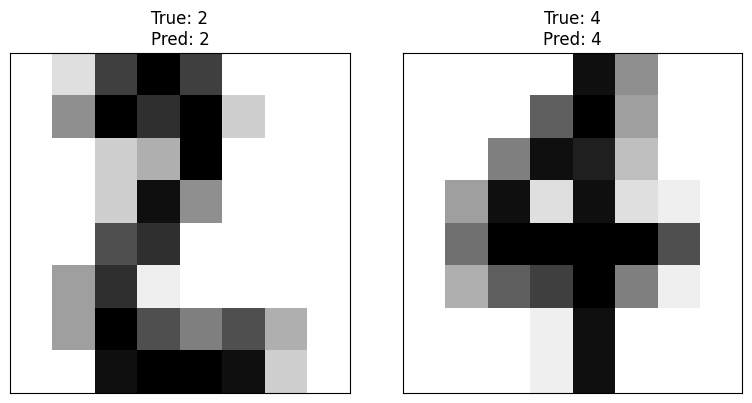

Sample 1: Actual Digit = 2, Predicted Digit = 2
Sample 2: Actual Digit = 4, Predicted Digit = 4


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

for i, ax in enumerate(axes):
    # Reshape the 64-feature array back into an 8x8 image
    image_data = sample_X[i].reshape(8, 8)
    ax.imshow(image_data, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'True: {sample_y_true[i]}\nPred: {sample_y_pred[i]}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Give the classification results
for i in range(len(sample_X)):
    print(f"Sample {i+1}: Actual Digit = {sample_y_true[i]}, Predicted Digit = {sample_y_pred[i]}")

In [ ]:
import numpy as np

digit_counts = np.bincount(df.target)

print("Count of each digit in the dataset:")
for digit, count in enumerate(digit_counts):
    print(f"Digit {digit}: {count} times")

Count of each digit in the dataset:
Digit 0: 178 times
Digit 1: 182 times
Digit 2: 177 times
Digit 3: 183 times
Digit 4: 181 times
Digit 5: 182 times
Digit 6: 181 times
Digit 7: 179 times
Digit 8: 174 times
Digit 9: 180 times
